### Explanation for Cell 1This cell executes: `import numpy as np`, `import matplotlib.pyplot as plt`, and `import seaborn as sns`.This explanation cell was added to describe what was done in the next cell.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Explanation for Cell 2This cell executes: `X_train = np.load("../processed_data/X_train.npy")`, `X_test = np.load("../processed_data/X_test.npy")`, and `y_train = np.load("../processed_data/y_train.npy")`.This explanation cell was added to describe what was done in the next cell.

In [2]:
X_train = np.load("../processed_data/X_train.npy")
X_test = np.load("../processed_data/X_test.npy")
y_train = np.load("../processed_data/y_train.npy")
y_test = np.load("../processed_data/y_test.npy")

print(X_train.shape, X_test.shape)

(17939, 64, 64, 3) (4485, 64, 64, 3)


### Explanation for Cell 3This cell executes: `X_train_small = X_train`, `y_train_small = y_train`, and `X_test_small = X_test`.This explanation cell was added to describe what was done in the next cell.

In [3]:
# use small subset
X_train_small = X_train
y_train_small = y_train

X_test_small = X_test
y_test_small = y_test

### Explanation for Cell 4This cell executes: `from keras.preprocessing.image import ImageDataGenerator`, `datagen = ImageDataGenerator(`, and `rotation_range=10,`.This explanation cell was added to describe what was done in the next cell.

In [ ]:
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

datagen.fit(X_train_small)

### Explanation for Cell 5This cell executes: `from keras import layers, models`, `model = models.Sequential([`, and `layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),`.This explanation cell was added to describe what was done in the next cell.

In [ ]:
from keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_small, y_train_small,
    epochs=5,
    validation_data=(X_test_small, y_test_small)
)

c:\Users\bakia\anaconda3\envs\driver_ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 62s 107ms/step - accuracy: 0.7078 - loss: 0.8544 - val_accuracy: 0.9469 - val_loss: 0.1912
Epoch 2/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.9691 - loss: 0.1163 - val_accuracy: 0.9710 - val_loss: 0.1084
Epoch 3/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.9849 - loss: 0.0522 - val_accuracy: 0.9819 - val_loss: 0.0666
Epoch 4/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - accuracy: 0.9875 - loss: 0.0416 - val_accuracy: 0.9719 - val_loss: 0.1157
Epoch 5/5
561/561 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - accuracy: 0.9907 - loss: 0.0294 - val_accuracy: 0.9799 - val_loss: 0.0783


### Explanation for Cell 6This cell executes: `plt.plot(history.history['accuracy'], label='train')`, `plt.plot(history.history['val_accuracy'], label='val')`, and `plt.title("CNN Accuracy")`.This explanation cell was added to describe what was done in the next cell.

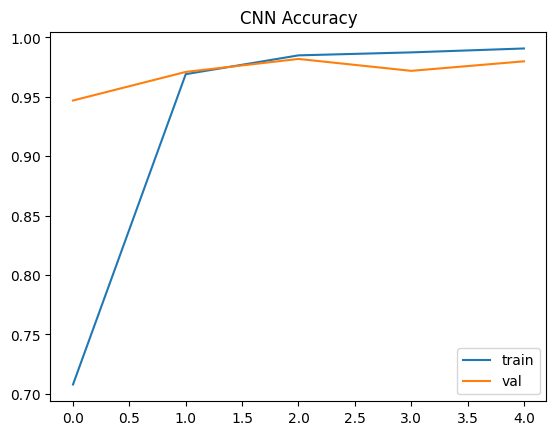

In [5]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("CNN Accuracy")
plt.legend()
plt.show()

### Explanation for Cell 7This cell executes: `from keras.applications import MobileNetV2`, `base_model = MobileNetV2(`, and `input_shape=(64,64,3),`.This explanation cell was added to describe what was done in the next cell.

In [ ]:
from keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(64,64,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    X_train_small, y_train_small,
    epochs=10,
    validation_data=(X_test_small, y_test_small),
)

C:\Users\bakia\AppData\Local\Temp\ipykernel_23052\3923761287.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 90s 146ms/step - accuracy: 0.7936 - loss: 0.6539 - val_accuracy: 0.5509 - val_loss: 3.2370
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 85s 151ms/step - accuracy: 0.9376 - loss: 0.2081 - val_accuracy: 0.8194 - val_loss: 1.1513
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 80s 143ms/step - accuracy: 0.9572 - loss: 0.1454 - val_accuracy: 0.9006 - val_loss: 0.5365
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 71s 126ms/step - accuracy: 0.9648 - loss: 0.1180 - val_accuracy: 0.9318 - val_loss: 0.2880
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 68s 122ms/step - accuracy: 0.9712 - loss: 0.0953 - val_accuracy: 0.9454 - val_loss: 0.2454
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 67s 120ms/step - accuracy: 0.9752 - loss: 0.0839 - val_accuracy: 0.9434 - val_loss: 0.2746
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 70s 125ms/step - accuracy: 0.9756 - loss: 0.0815 - val_accuracy: 0.9552 - val_loss: 0.2460
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 74s 132ms/step - accuracy: 0.9794 - loss: 0

### Explanation for Cell 8This cell executes: `plt.figure(figsize=(8, 5))`, `plt.plot(history_tl.history['accuracy'], label='Train Accuracy')`, and `plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')`.This explanation cell was added to describe what was done in the next cell.

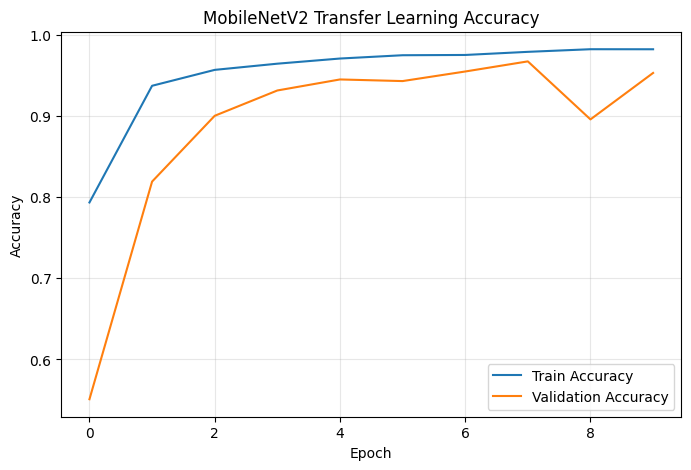

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Explanation for Cell 9This cell executes: `from sklearn.metrics import classification_report`, `y_pred = np.argmax(model.predict(X_test_small), axis=1)`, and `print("CNN Classification Report:")`.This explanation cell was added to describe what was done in the next cell.

In [10]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test_small), axis=1)
print("CNN Classification Report:")
print(classification_report(y_test_small, y_pred))

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
CNN Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       498
           1       0.98      1.00      0.99       453
           2       0.98      1.00      0.99       464
           3       0.98      0.99      0.99       469
           4       0.99      0.99      0.99       465
           5       1.00      0.99      0.99       463
           6       1.00      0.98      0.99       465
           7       0.98      0.99      0.99       400
           8       1.00      0.89      0.94       382
           9       0.93      0.99      0.96       426

    accuracy                           0.98      4485
   macro avg       0.98      0.98      0.98      4485
weighted avg       0.98      0.98      0.98      4485



### Explanation for Cell 10This cell executes: `from sklearn.metrics import confusion_matrix`, `print("CNN confusion matrix:")`, and `cm = confusion_matrix(y_test, y_pred)`.This explanation cell was added to describe what was done in the next cell.

CNN confusion matrix:


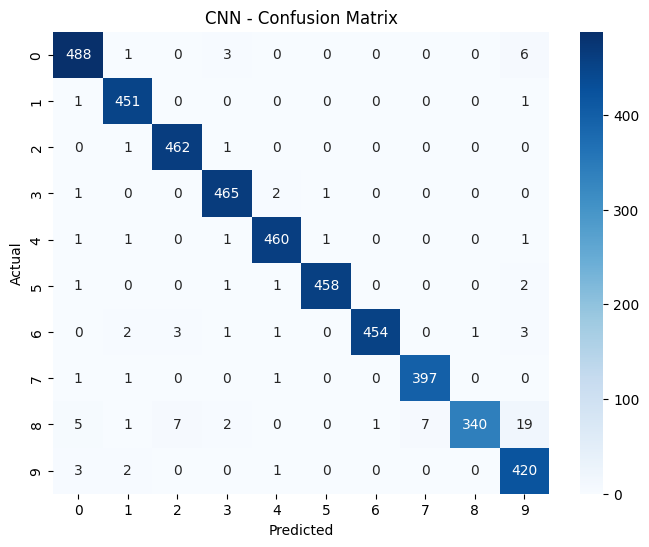

In [ ]:
from sklearn.metrics import confusion_matrix
print("CNN confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explanation for Cell 11This cell executes: `from sklearn.metrics import classification_report`, `y_pred = np.argmax(model_tl.predict(X_test_small), axis=1)`, and `print("Transfer Learning Classification Report:")`.This explanation cell was added to describe what was done in the next cell.

In [13]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model_tl.predict(X_test_small), axis=1)
print("Transfer Learning Classification Report:")
print(classification_report(y_test_small, y_pred))

141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step
Transfer Learning Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92       498
           1       0.90      1.00      0.95       453
           2       1.00      0.91      0.95       464
           3       0.95      0.98      0.96       469
           4       0.95      0.95      0.95       465
           5       0.98      0.99      0.99       463
           6       0.93      0.99      0.96       465
           7       1.00      0.95      0.97       400
           8       0.93      0.93      0.93       382
           9       0.92      0.97      0.95       426

    accuracy                           0.95      4485
   macro avg       0.95      0.95      0.95      4485
weighted avg       0.96      0.95      0.95      4485



### Explanation for Cell 12This cell executes: `from sklearn.metrics import confusion_matrix`, `cm = confusion_matrix(y_test_small, y_pred)`, and `plt.figure(figsize=(8,6))`.This explanation cell was added to describe what was done in the next cell.

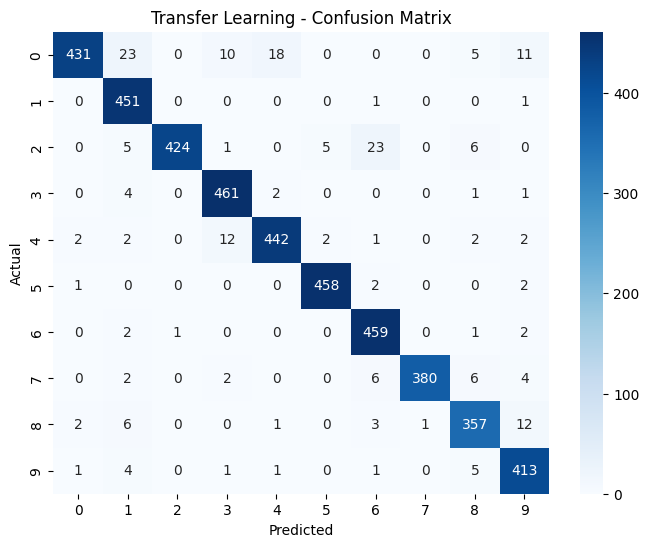

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_small, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Transfer Learning - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explanation for Cell 13This cell executes: `model.save("../models/cnn_model.keras")` and `model_tl.save("../models/transfer_model.keras")`.This explanation cell was added to describe what was done in the next cell.

In [17]:
model.save("../models/cnn_model.keras")
model_tl.save("../models/transfer_model.keras")

### Explanation for Cell 14This cell executes: `import tensorflow as tf`, `import numpy as np`, and `import cv2`.This explanation cell was added to describe what was done in the next cell.

In [22]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Rebuild an intermediate functional model layer-by-layer
    # (avoids .output AttributeError on Sequential models in Keras 3)
    inp = tf.keras.Input(shape=img_array.shape[1:])
    x = inp
    conv_out = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_out = x
    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out, x])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        tape.watch(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

### Explanation for Cell 15This cell executes: `img = X_test_small[4]`, `img_array = np.expand_dims(img, axis=0)`, and `heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2")`.This explanation cell was added to describe what was done in the next cell.

In [39]:
img = X_test_small[4]
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv2d_2")

### Explanation for Cell 16This cell executes: `heatmap = cv2.resize(heatmap, (64,64))`, `heatmap = np.uint8(255 * heatmap)`, and `plt.imshow(img)`.This explanation cell was added to describe what was done in the next cell.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

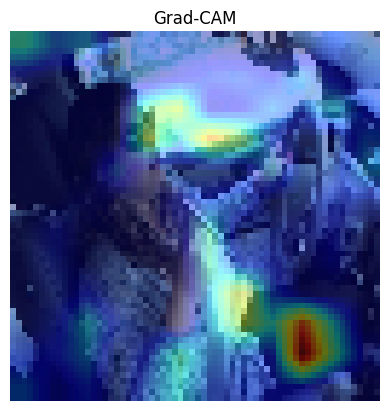

In [35]:
heatmap = cv2.resize(heatmap, (64,64))
heatmap = np.uint8(255 * heatmap)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.title("Grad-CAM")
plt.axis('off')

### Explanation for Cell 17This cell executes: `model_rnn = tf.keras.Sequential([`, `tf.keras.layers.Reshape((64, 64*3), input_shape=(64,64,3)),`, and `tf.keras.layers.LSTM(128, return_sequences=False),`.This explanation cell was added to describe what was done in the next cell.

In [36]:
model_rnn = tf.keras.Sequential([
    tf.keras.layers.Reshape((64, 64*3), input_shape=(64,64,3)),
    tf.keras.layers.LSTM(128, return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_rnn = model_rnn.fit(
    X_train_small, y_train_small,
    epochs=8,
    validation_data=(X_test_small, y_test_small)
)

c:\Users\bakia\anaconda3\envs\driver_ml\lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.3704 - loss: 1.6681 - val_accuracy: 0.5532 - val_loss: 1.1792
Epoch 2/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.6310 - loss: 0.9808 - val_accuracy: 0.7474 - val_loss: 0.7070
Epoch 3/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.7787 - loss: 0.6259 - val_accuracy: 0.8265 - val_loss: 0.5034
Epoch 4/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.8545 - loss: 0.4394 - val_accuracy: 0.9072 - val_loss: 0.3124
Epoch 5/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.8930 - loss: 0.3317 - val_accuracy: 0.9242 - val_loss: 0.2500
Epoch 6/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.9236 - loss: 0.2458 - val_accuracy: 0.9534 - val_loss: 0.1688
Epoch 7/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.9336 - loss: 0.2108 - val_accuracy: 0.9460 - val_loss: 0.1828
Epoch 8/8
561/561 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.9462 - loss: 0.1798 - val_accu

### Explanation for Cell 18This cell executes: `plt.figure(figsize=(8, 5))`, `plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')`, and `plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')`.This explanation cell was added to describe what was done in the next cell.

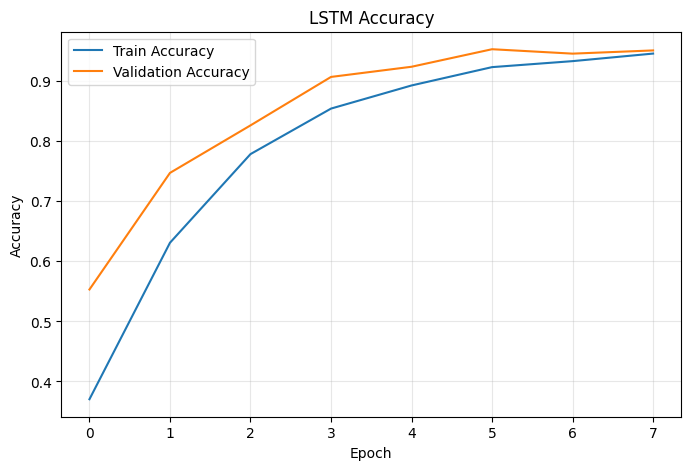

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Explanation for Cell 19This cell executes: `from sklearn.metrics import classification_report`, `y_pred = np.argmax(model_rnn.predict(X_test_small), axis=1)`, and `print("LSTM Classification Report:")`.This explanation cell was added to describe what was done in the next cell.

In [45]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model_rnn.predict(X_test_small), axis=1)
print("LSTM Classification Report:")
print(classification_report(y_test_small, y_pred))

141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       498
           1       0.99      0.98      0.98       453
           2       0.99      0.96      0.97       464
           3       0.90      0.96      0.93       469
           4       0.93      0.89      0.91       465
           5       1.00      0.97      0.98       463
           6       0.96      0.99      0.97       465
           7       0.97      0.99      0.98       400
           8       0.97      0.89      0.93       382
           9       0.92      0.92      0.92       426

    accuracy                           0.95      4485
   macro avg       0.95      0.95      0.95      4485
weighted avg       0.95      0.95      0.95      4485



### Explanation for Cell 20This cell executes: `from sklearn.metrics import confusion_matrix`, `cm = confusion_matrix(y_test_small, y_pred)`, and `plt.figure(figsize=(8,6))`.This explanation cell was added to describe what was done in the next cell.

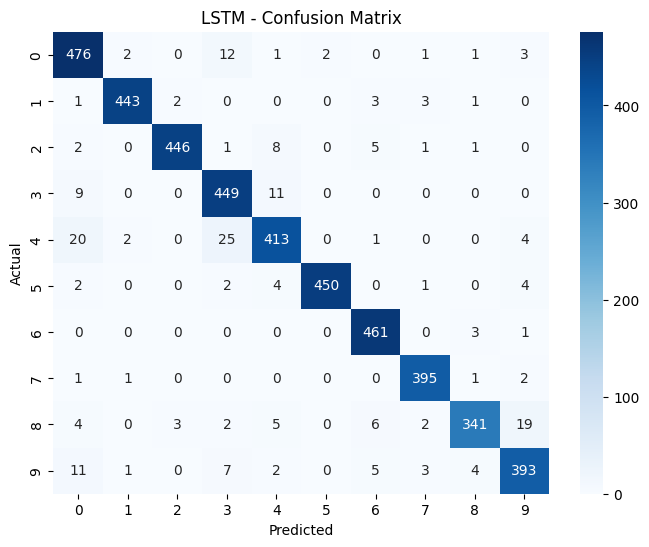

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_small, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explanation for Cell 21This cell executes: `from keras.layers import MultiHeadAttention, LayerNormalization`, `inputs = tf.keras.Input(shape=(64,64,3))`, and `x = tf.keras.layers.Reshape((64, 64*3))(inputs)`.This explanation cell was added to describe what was done in the next cell.

In [ ]:
from keras.layers import MultiHeadAttention, LayerNormalization

inputs = tf.keras.Input(shape=(64,64,3))

x = tf.keras.layers.Reshape((64, 64*3))(inputs)

attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization()(attn_output + x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model_transformer = tf.keras.Model(inputs, outputs)

model_transformer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_trans = model_transformer.fit(
    X_train_small, y_train_small,
    epochs=6,
    validation_data=(X_test_small, y_test_small)
)

Epoch 1/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.3808 - loss: 1.7147 - val_accuracy: 0.6713 - val_loss: 0.9866
Epoch 2/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.6954 - loss: 0.8904 - val_accuracy: 0.8225 - val_loss: 0.6015
Epoch 3/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step - accuracy: 0.7945 - loss: 0.6281 - val_accuracy: 0.8453 - val_loss: 0.5052
Epoch 4/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.8270 - loss: 0.5279 - val_accuracy: 0.8334 - val_loss: 0.5294
Epoch 5/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.8567 - loss: 0.4385 - val_accuracy: 0.8965 - val_loss: 0.3568
Epoch 6/6
561/561 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8694 - loss: 0.4012 - val_accuracy: 0.9030 - val_loss: 0.3279


### Explanation for Cell 22This cell executes: `plt.figure(figsize=(8, 5))`, `plt.plot(history_trans.history['accuracy'], label='Train Accuracy')`, and `plt.plot(history_trans.history['val_accuracy'], label='Validation Accuracy')`.This explanation cell was added to describe what was done in the next cell.

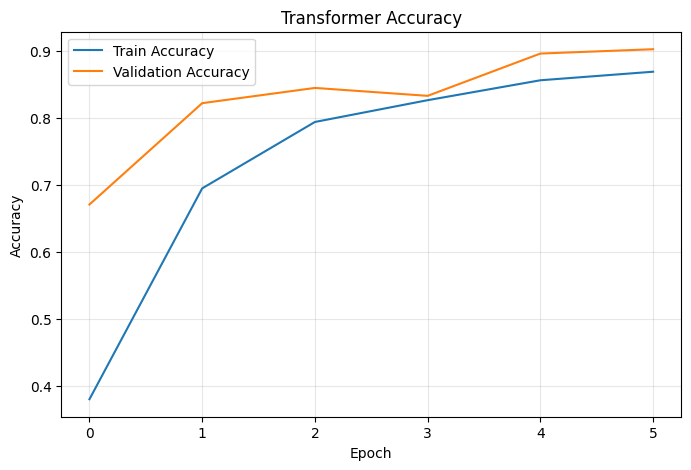

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(history_trans.history['accuracy'], label='Train Accuracy')
plt.plot(history_trans.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transformer Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Explanation for Cell 23This cell executes: `from sklearn.metrics import classification_report`, `y_pred = np.argmax(model_transformer.predict(X_test_small), axis=1)`, and `print("Transformer Classification Report:")`.This explanation cell was added to describe what was done in the next cell.

In [44]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model_transformer.predict(X_test_small), axis=1)
print("Transformer Classification Report:")
print(classification_report(y_test_small, y_pred))

141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Transformer Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       498
           1       0.94      0.98      0.96       453
           2       0.95      0.94      0.95       464
           3       0.91      0.82      0.86       469
           4       0.79      0.88      0.83       465
           5       0.95      0.93      0.94       463
           6       0.92      0.95      0.94       465
           7       0.96      0.95      0.96       400
           8       0.79      0.89      0.83       382
           9       0.92      0.80      0.86       426

    accuracy                           0.90      4485
   macro avg       0.90      0.90      0.90      4485
weighted avg       0.91      0.90      0.90      4485



### Explanation for Cell 24This cell executes: `from sklearn.metrics import confusion_matrix`, `cm = confusion_matrix(y_test_small, y_pred)`, and `plt.figure(figsize=(8,6))`.This explanation cell was added to describe what was done in the next cell.

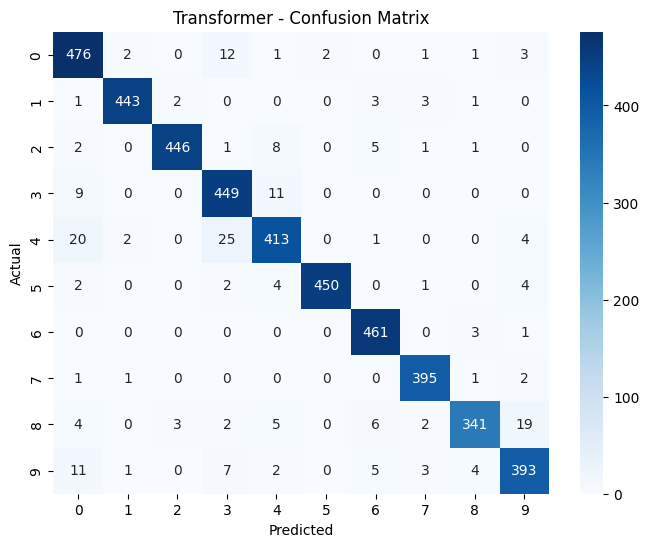

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_small, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Transformer - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explanation for Cell 25This cell executes: `model_rnn.save("../models/rnn_model.keras")` and `model_transformer.save("../models/transformer_model.keras")`.This explanation cell was added to describe what was done in the next cell.

In [47]:
model_rnn.save("../models/rnn_model.keras")
model_transformer.save("../models/transformer_model.keras")

### Explanation for Cell 26This cell executes: `results_dl = {`, `"CNN": model.evaluate(X_test_small, y_test_small)[1],`, and `"Transfer": model_tl.evaluate(X_test_small, y_test_small)[1],`.This explanation cell was added to describe what was done in the next cell.

In [48]:
results_dl = {
    "CNN": model.evaluate(X_test_small, y_test_small)[1],
    "Transfer": model_tl.evaluate(X_test_small, y_test_small)[1],
    "RNN": model_rnn.evaluate(X_test_small, y_test_small)[1],
    "Transformer": model_transformer.evaluate(X_test_small, y_test_small)[1]
}

for k,v in results_dl.items():
    print(k, ":", v)

141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9799 - loss: 0.0783
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9534 - loss: 0.2205
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9514 - loss: 0.1770
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9030 - loss: 0.3279
CNN : 0.9799330830574036
Transfer : 0.953400194644928
RNN : 0.9513935446739197
Transformer : 0.9030100107192993


### Explanation for Cell 27This cell executes: `from sklearn.metrics import roc_curve, auc`, `from sklearn.preprocessing import label_binarize`, and `y_test_bin = label_binarize(y_test_small, classes=np.unique(y_test_small))`.This explanation cell was added to describe what was done in the next cell.

141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


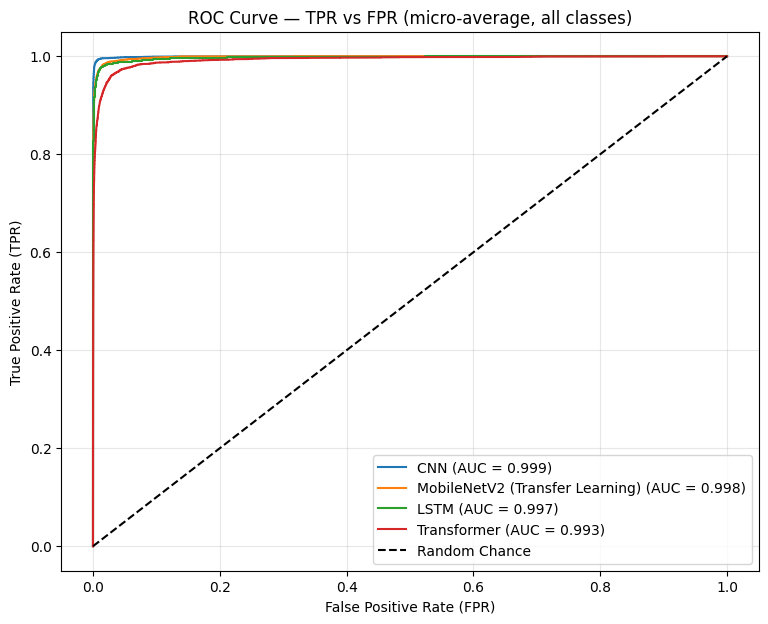

In [49]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_small, classes=np.unique(y_test_small))

def plot_roc_curve(y_prob, label):
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

prob_cnn         = model.predict(X_test_small)
prob_tl          = model_tl.predict(X_test_small)
prob_rnn         = model_rnn.predict(X_test_small)
prob_transformer = model_transformer.predict(X_test_small)

plt.figure(figsize=(9, 7))
plot_roc_curve(prob_cnn,         "CNN")
plot_roc_curve(prob_tl,          "MobileNetV2 (Transfer Learning)")
plot_roc_curve(prob_rnn,         "LSTM")
plot_roc_curve(prob_transformer, "Transformer")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve — TPR vs FPR (micro-average, all classes)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()

### Explanation for Cell 28This markdown cell introduces the section: **Final Summary: Deep Learning Models**.This explanation cell was added to describe what was done in the next cell.

# Final Summary: Deep Learning Models

## What We Did

- Loaded processed train/test image arrays.
- Trained and evaluated multiple deep models for distracted-driver classification:
  - Custom CNN
  - MobileNetV2 transfer learning
  - LSTM-based sequence-style model over reshaped image rows
  - Transformer-style attention model
- Tracked learning curves (accuracy plots) and generated classification reports/confusion matrices.
- Built a combined ROC (TPR vs FPR, micro-average) comparison across deep models.
- Saved trained deep models to the models folder.
- Added Grad-CAM visualization to interpret CNN focus regions.

## What We Observed

- Deep models clearly outperformed simpler non-deep baselines for this image task.
- MobileNetV2 transfer learning achieved very strong validation behavior with high ROC performance.
- CNN and transfer learning were especially stable and accurate compared with experimental sequence/attention variants.
- LSTM and transformer variants were informative experiments, but they are less naturally aligned than CNN-style feature extraction for this dataset resolution and setup.
- ROC and confusion matrices show strong separability overall, with remaining confusion concentrated in visually similar distraction classes.

## Conclusion

Deep learning is the most effective approach in this project, especially transfer learning. It gives the best balance of predictive performance and practical workflow, while Grad-CAM also improves interpretability of model decisions.